# Migração de Bases Relacionais para NoSQL
## PostgreSQL → Neo4j com Python

Este notebook demonstra como migrar um banco relacional (**PostgreSQL**) para um banco de grafos (**Neo4j**), cobrindo:

- Criação de um schema relacional real (Livraria Online com 6 tabelas e FKs)
- **Mapeamento conceitual**: Tabela → Nó, Linha → Nó, Chave Estrangeira → Relacionamento
- **Migração em Python** usando batching com `UNWIND` no Cypher
- **Benchmark de queries**: SQL com JOINs vs. Cypher com traversal
- Visualizações comparativas de performance

## 1. Instalação das Dependências

In [1]:
# Caso necessário
# %pip install --upgrade jupyter
%pip install psycopg2-binary neo4j faker pandas matplotlib seaborn tqdm psutil jinja2 ipywidgets --quiet

Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


## 2. Importações

In [2]:
import time
import random
import psutil
import os
import uuid
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from datetime import datetime
from faker import Faker
from tqdm.notebook import tqdm
import psycopg2
from psycopg2.extras import execute_batch
from neo4j import GraphDatabase

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

fake = Faker('pt_BR')
Faker.seed(42)
random.seed(42)

print("Dependências importadas com sucesso!")

Dependências importadas com sucesso!


## 3. Configurações de Conexão

> **Pessoal: É necessário configurar as credenciais dos seus bancos de dados abaixo.**
> **A qui ou em casa, opr favor ok.**

In [3]:
# ─── PostgreSQL ───────────────────────────────────────────
PG_CONFIG = {
    'host':     'localhost',
    'port':     5432,
    'dbname':   'postgres',
    'user':     'postgres',
    'password': 'univassouras' #<-- Altere para a senha do seu PostgreSQL
}

# ─── Neo4j ────────────────────────────────────────────────
NEO4J_URI      = 'neo4j://127.0.0.1:7687'
NEO4J_USER     = 'neo4j'
NEO4J_PASSWORD = 'univassouras' #<-- Altere para a senha do seu Neo4j

# ─── Parâmetros do experimento ────────────────────────────
N_AUTORES    = 50
N_CATEGORIAS = 20
N_LIVROS     = 500
N_CLIENTES   = 1_000
N_PEDIDOS    = 2_000
BATCH_SIZE   = 500
N_BENCH_REPS = 10

ESTADOS_BR = ['AC','AL','AM','AP','BA','CE','DF','ES','GO','MA',
               'MG','MS','MT','PA','PB','PE','PI','PR','RJ','RN',
               'RO','RR','RS','SC','SE','SP','TO']

print(f"{'Entidade':<18} {'Registros':>10}")
print("-" * 30)
for nome, n in [('Autores', N_AUTORES), ('Categorias', N_CATEGORIAS),
                ('Livros', N_LIVROS), ('Clientes', N_CLIENTES), ('Pedidos', N_PEDIDOS)]:
    print(f"  {nome:<16} {n:>10,}")

Entidade            Registros
------------------------------
  Autores                  50
  Categorias               20
  Livros                  500
  Clientes              1,000
  Pedidos               2,000


## 4. Schema Relacional — Livraria Online

Criamos um domínio de livraria com **6 tabelas** e **4 chaves estrangeiras**:

```
autores ←── livros ──→ categorias
               ↑
          itens_pedido
               ↑
            pedidos ──→ clientes
```

A tabela `itens_pedido` é uma **tabela de junção** (junction table) com propriedades (`quantidade`, `preco_unitario`).
No Neo4j, ela se tornará um **relacionamento com propriedades**: `(:Pedido)-[:CONTEM {quantidade, preco_unitario}]->(:Livro)`.

In [4]:
GENEROS = ['Romance', 'Ficcao Cientifica', 'Terror', 'Fantasia', 'Biografia',
           'Historia', 'Tecnologia', 'Ciencia', 'Autoajuda', 'Infantil',
           'Suspense', 'Policial', 'Poesia', 'Cronicas', 'Filosofia',
           'Psicologia', 'Economia', 'Direito', 'Medicina', 'Arte']


def criar_schema_postgres(config: dict) -> None:
    """Recria as tabelas da livraria no PostgreSQL."""
    conn = psycopg2.connect(**config)
    conn.autocommit = True
    cur = conn.cursor()
    cur.execute("DROP TABLE IF EXISTS itens_pedido, pedidos, livros, clientes, autores, categorias CASCADE")
    cur.execute("""CREATE TABLE autores (
        id SERIAL PRIMARY KEY, nome VARCHAR(120),
        nacionalidade VARCHAR(60), ano_nascimento SMALLINT)""")
    cur.execute("""CREATE TABLE categorias (
        id SERIAL PRIMARY KEY, nome VARCHAR(80), descricao TEXT)""")
    cur.execute("""CREATE TABLE livros (
        id SERIAL PRIMARY KEY, titulo VARCHAR(200), isbn VARCHAR(20) UNIQUE,
        preco NUMERIC(8,2), ano_publicacao SMALLINT,
        autor_id INT REFERENCES autores(id),
        categoria_id INT REFERENCES categorias(id),
        avaliacao_media FLOAT)""")
    cur.execute("""CREATE TABLE clientes (
        id SERIAL PRIMARY KEY, nome VARCHAR(120),
        email VARCHAR(200) UNIQUE, cidade VARCHAR(100),
        estado CHAR(2), membro_desde DATE)""")
    cur.execute("""CREATE TABLE pedidos (
        id SERIAL PRIMARY KEY, cliente_id INT REFERENCES clientes(id),
        data_pedido TIMESTAMP, total NUMERIC(10,2), status VARCHAR(30))""")
    cur.execute("""CREATE TABLE itens_pedido (
        id SERIAL PRIMARY KEY, pedido_id INT REFERENCES pedidos(id),
        livro_id INT REFERENCES livros(id),
        quantidade SMALLINT, preco_unitario NUMERIC(8,2))""")
    cur.close()
    conn.close()
    print("Schema PostgreSQL criado: 6 tabelas, 4 chaves estrangeiras.")


def popular_postgres(config: dict) -> int:
    """Gera e insere dados sintéticos no PostgreSQL. Retorna total de itens."""
    conn = psycopg2.connect(**config)
    cur  = conn.cursor()
    t0   = time.perf_counter()

    # Autores
    autores = [{'nome': fake.name(),
                'nacionalidade': random.choice(['Brasileira','Americana','Britanica','Francesa','Portuguesa']),
                'ano_nascimento': random.randint(1920, 1990)}
               for _ in range(N_AUTORES)]
    execute_batch(cur,
        "INSERT INTO autores(nome,nacionalidade,ano_nascimento) "
        "VALUES(%(nome)s,%(nacionalidade)s,%(ano_nascimento)s)", autores)
    conn.commit()

    # Categorias
    categorias = [{'nome': g, 'descricao': f'Obras de {g.lower()} para todos os publicos'}
                  for g in GENEROS[:N_CATEGORIAS]]
    execute_batch(cur,
        "INSERT INTO categorias(nome,descricao) VALUES(%(nome)s,%(descricao)s)", categorias)
    conn.commit()

    # Livros
    adj = ['O Ultimo','A Grande','O Segredo do','A Sombra de','O Fim do',
           'A Luz do','O Misterio de','A Jornada do','O Despertar de','A Queda do']
    livros = [{'titulo': f"{random.choice(adj)} {fake.last_name()}",
               'isbn': uuid.uuid4().hex[:13].upper(),
               'preco': round(random.uniform(19.90, 149.90), 2),
               'ano_publicacao': random.randint(1980, 2024),
               'autor_id': random.randint(1, N_AUTORES),
               'categoria_id': random.randint(1, N_CATEGORIAS),
               'avaliacao_media': round(random.uniform(2.5, 5.0), 1)}
              for _ in range(N_LIVROS)]
    execute_batch(cur,
        "INSERT INTO livros(titulo,isbn,preco,ano_publicacao,autor_id,categoria_id,avaliacao_media) "
        "VALUES(%(titulo)s,%(isbn)s,%(preco)s,%(ano_publicacao)s,%(autor_id)s,%(categoria_id)s,%(avaliacao_media)s)",
        livros)
    conn.commit()

    # Clientes
    clientes = [{'nome': fake.name(),
                 'email': f"{uuid.uuid4().hex[:8]}@{fake.free_email_domain()}",
                 'cidade': fake.city(),
                 'estado': random.choice(ESTADOS_BR),
                 'membro_desde': fake.date_between(start_date='-5y', end_date='today')}
                for _ in range(N_CLIENTES)]
    execute_batch(cur,
        "INSERT INTO clientes(nome,email,cidade,estado,membro_desde) "
        "VALUES(%(nome)s,%(email)s,%(cidade)s,%(estado)s,%(membro_desde)s)", clientes)
    conn.commit()

    # Pedidos
    status_opts = ['entregue', 'enviado', 'processando', 'cancelado']
    pedidos = [{'cliente_id': random.randint(1, N_CLIENTES),
                'data_pedido': fake.date_time_between(start_date='-2y', end_date='now'),
                'total': 0,
                'status': random.choices(status_opts, weights=[60, 25, 10, 5])[0]}
               for _ in range(N_PEDIDOS)]
    execute_batch(cur,
        "INSERT INTO pedidos(cliente_id,data_pedido,total,status) "
        "VALUES(%(cliente_id)s,%(data_pedido)s,%(total)s,%(status)s)", pedidos)
    conn.commit()

    # Itens de pedido (tabela de juncao)
    cur.execute("SELECT id FROM pedidos ORDER BY id")
    pedido_ids = [r[0] for r in cur.fetchall()]
    itens = []
    for pid in pedido_ids:
        for lid in random.sample(range(1, N_LIVROS + 1), random.randint(1, 4)):
            itens.append({'pedido_id': pid, 'livro_id': lid,
                          'quantidade': random.randint(1, 3),
                          'preco_unitario': round(random.uniform(19.90, 149.90), 2)})
    execute_batch(cur,
        "INSERT INTO itens_pedido(pedido_id,livro_id,quantidade,preco_unitario) "
        "VALUES(%(pedido_id)s,%(livro_id)s,%(quantidade)s,%(preco_unitario)s)", itens)
    conn.commit()

    cur.execute("""UPDATE pedidos p SET total = (
        SELECT COALESCE(SUM(quantidade * preco_unitario), 0)
        FROM itens_pedido WHERE pedido_id = p.id)""")
    conn.commit()

    tempo = time.perf_counter() - t0
    total = N_AUTORES + N_CATEGORIAS + N_LIVROS + N_CLIENTES + N_PEDIDOS + len(itens)
    cur.close()
    conn.close()
    print(f"PostgreSQL populado em {tempo:.2f}s — {total:,} registros totais")
    print(f"  {len(itens):,} itens_pedido = tabela de juncao que vira relacionamento no grafo")
    return len(itens)

In [5]:
criar_schema_postgres(PG_CONFIG)
n_itens = popular_postgres(PG_CONFIG)

Schema PostgreSQL criado: 6 tabelas, 4 chaves estrangeiras.
PostgreSQL populado em 0.66s — 8,570 registros totais
  5,000 itens_pedido = tabela de juncao que vira relacionamento no grafo


## 5. Mapeamento Conceitual: Relacional → Grafo

Esta é a **regra central** da migração. Cada conceito do modelo relacional tem um equivalente no modelo de grafos:

| Relacional | → | Neo4j (Grafo) | Exemplo |
|---|---|---|---|
| Tabela | → | Label | `autores` → `:Autor` |
| Linha | → | Nó | `{id:1, nome:'...'}` → `(a:Autor {id:1, nome:'...'})` |
| Coluna | → | Propriedade | `nome VARCHAR` → `.nome` |
| Chave Estrangeira | → | Relacionamento | `autor_id` → `-[:ESCRITO_POR]->` |
| Tabela de Junção | → | Relacionamento com props | `itens_pedido` → `-[:CONTEM {quantidade, preco}]->` |
| JOIN | → | Travessia | `JOIN livros ON id = autor_id` → `-[:ESCRITO_POR]->` |

In [6]:
mapeamento = pd.DataFrame([
    {'Tabela PostgreSQL': 'autores',      'Label Neo4j': ':Autor',     'Relacionamentos de Saída': '—',
     'Tipo de Migração': 'Nó simples'},
    {'Tabela PostgreSQL': 'categorias',   'Label Neo4j': ':Categoria', 'Relacionamentos de Saída': '—',
     'Tipo de Migração': 'Nó simples'},
    {'Tabela PostgreSQL': 'livros',       'Label Neo4j': ':Livro',     'Relacionamentos de Saída': '-[:ESCRITO_POR]->(:Autor), -[:PERTENCE_A]->(:Categoria)',
     'Tipo de Migração': 'Nó + 2 FKs'},
    {'Tabela PostgreSQL': 'clientes',     'Label Neo4j': ':Cliente',   'Relacionamentos de Saída': '—',
     'Tipo de Migração': 'Nó simples'},
    {'Tabela PostgreSQL': 'pedidos',      'Label Neo4j': ':Pedido',    'Relacionamentos de Saída': '-[:FEITO_POR]->(:Cliente)',
     'Tipo de Migração': 'Nó + 1 FK'},
    {'Tabela PostgreSQL': 'itens_pedido', 'Label Neo4j': '—',          'Relacionamentos de Saída': '-[:CONTEM {quantidade, preco_unitario}]->(:Livro)',
     'Tipo de Migração': 'Tabela de Juncao → Relacionamento'},
])

mapeamento.style.set_caption('Mapeamento Conceitual: PostgreSQL → Neo4j').hide(axis='index')

Tabela PostgreSQL,Label Neo4j,Relacionamentos de Saída,Tipo de Migração
autores,:Autor,—,Nó simples
categorias,:Categoria,—,Nó simples
livros,:Livro,"-[:ESCRITO_POR]->(:Autor), -[:PERTENCE_A]->(:Categoria)",Nó + 2 FKs
clientes,:Cliente,—,Nó simples
pedidos,:Pedido,-[:FEITO_POR]->(:Cliente),Nó + 1 FK
itens_pedido,—,"-[:CONTEM {quantidade, preco_unitario}]->(:Livro)",Tabela de Juncao → Relacionamento


## 6. Migração: PostgreSQL → Neo4j

A migração segue **3 fases**:

1. **Preparação**: Limpar o Neo4j e criar índices (fundamental para performance do MERGE)
2. **Migrar Nós**: Ler cada tabela do PG e criar os nós correspondentes no Neo4j com `UNWIND + MERGE`
3. **Migrar Relacionamentos**: Ler os valores de FK e criar as arestas com `MATCH + MERGE`

> **Por que `MERGE` e não `CREATE`?** `MERGE` garante idempotência — se a migração falhar e for reiniciada, não cria duplicatas.

In [7]:
def preparar_neo4j(uri: str, user: str, password: str) -> None:
    """Limpa o banco Neo4j e cria índices para as propriedades de busca."""
    driver = GraphDatabase.driver(uri, auth=(user, password))
    with driver.session() as s:
        s.run("MATCH (n) DETACH DELETE n")
        # Indices tornam o MATCH na criacao de relacionamentos muito mais rapido
        for label, prop in [('Autor','id'),('Categoria','id'),
                             ('Livro','id'),('Cliente','id'),('Pedido','id')]:
            s.run(f"CREATE INDEX {label.lower()}_id IF NOT EXISTS FOR (n:{label}) ON (n.{prop})")
    driver.close()
    print("Neo4j preparado — banco limpo, 5 indices criados.")


preparar_neo4j(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD)

Neo4j preparado — banco limpo, 5 indices criados.


### 6.1 Fase 1 — Migrando Nós (Entidades)

In [8]:
def migrar_nos(pg_config: dict, uri: str, user: str, password: str,
               batch_size: int = 500) -> dict:
    """
    Le cada tabela-entidade do PostgreSQL e cria os nos correspondentes no Neo4j.
    Usa UNWIND para criacao em batch — muito mais eficiente do que um MERGE por vez.
    """
    conn   = psycopg2.connect(**pg_config)
    cur    = conn.cursor()
    driver = GraphDatabase.driver(uri, auth=(user, password))
    res    = {}

    entidades = [
        ('Autor',     'SELECT id, nome, nacionalidade, ano_nascimento FROM autores',
         lambda r: {'id': r[0], 'nome': r[1], 'nacionalidade': r[2], 'ano_nascimento': r[3]},
         "UNWIND $lote AS row MERGE (n:Autor {id: row.id}) "
         "SET n.nome=row.nome, n.nacionalidade=row.nacionalidade, n.ano_nascimento=row.ano_nascimento"),

        ('Categoria', 'SELECT id, nome, descricao FROM categorias',
         lambda r: {'id': r[0], 'nome': r[1], 'descricao': r[2]},
         "UNWIND $lote AS row MERGE (n:Categoria {id: row.id}) SET n.nome=row.nome, n.descricao=row.descricao"),

        ('Livro',     'SELECT id, titulo, isbn, preco, ano_publicacao, avaliacao_media FROM livros',
         lambda r: {'id': r[0], 'titulo': r[1], 'isbn': r[2],
                    'preco': float(r[3]), 'ano_publicacao': r[4], 'avaliacao_media': r[5]},
         "UNWIND $lote AS row MERGE (n:Livro {id: row.id}) "
         "SET n.titulo=row.titulo, n.isbn=row.isbn, n.preco=row.preco, "
         "n.ano_publicacao=row.ano_publicacao, n.avaliacao_media=row.avaliacao_media"),

        ('Cliente',   'SELECT id, nome, email, cidade, estado, membro_desde FROM clientes',
         lambda r: {'id': r[0], 'nome': r[1], 'email': r[2],
                    'cidade': r[3], 'estado': r[4], 'membro_desde': str(r[5])},
         "UNWIND $lote AS row MERGE (n:Cliente {id: row.id}) "
         "SET n.nome=row.nome, n.email=row.email, n.cidade=row.cidade, "
         "n.estado=row.estado, n.membro_desde=row.membro_desde"),

        ('Pedido',    'SELECT id, data_pedido, total, status FROM pedidos',
         lambda r: {'id': r[0], 'data_pedido': str(r[1]), 'total': float(r[2]), 'status': r[3]},
         "UNWIND $lote AS row MERGE (n:Pedido {id: row.id}) "
         "SET n.data_pedido=row.data_pedido, n.total=row.total, n.status=row.status"),
    ]

    inicio = time.perf_counter()
    for label, sql, mapper, cypher in tqdm(entidades, desc='Migrando nos'):
        cur.execute(sql)
        rows = [mapper(r) for r in cur.fetchall()]
        t0   = time.perf_counter()
        with driver.session() as s:
            for i in range(0, len(rows), batch_size):
                s.run(cypher, lote=rows[i:i+batch_size])
        t = time.perf_counter() - t0
        res[label] = {'count': len(rows), 'tempo_s': round(t, 3)}
        print(f"  {label:<12} {len(rows):>6,} nos  →  {t:.3f}s")

    res['_total_s'] = round(time.perf_counter() - inicio, 2)
    cur.close(); conn.close(); driver.close()
    print(f"\nFase 1 concluida em {res['_total_s']}s")
    return res

In [9]:
print("=== FASE 1: Migrando Nos ===")
resultado_nos = migrar_nos(PG_CONFIG, NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, BATCH_SIZE)

=== FASE 1: Migrando Nos ===


Migrando nos:   0%|          | 0/5 [00:00<?, ?it/s]

  Autor            50 nos  →  0.483s
  Categoria        20 nos  →  0.075s
  Livro           500 nos  →  0.223s
  Cliente       1,000 nos  →  0.227s
  Pedido        2,000 nos  →  0.217s

Fase 1 concluida em 1.27s


### 6.2 Fase 2 — Migrando Relacionamentos (Chaves Estrangeiras)

Cada FK na tabela `livros` vira um relacionamento. A tabela de junção `itens_pedido` vira um relacionamento **com propriedades**.

**Padrão Cypher para relacionamentos**:
```cypher
UNWIND $lote AS row
MATCH (a {id: row.id_origem}), (b {id: row.id_destino})
MERGE (a)-[:TIPO_REL]->(b)
```
O `MATCH` localiza os nós usando os índices criados na preparação. Sem índice, cada MATCH faria um full scan.

In [10]:
def migrar_relacionamentos(pg_config: dict, uri: str, user: str, password: str,
                           batch_size: int = 500) -> dict:
    """
    Le os valores de FK do PostgreSQL e cria relacionamentos no Neo4j.
    A tabela de juncao itens_pedido vira um relacionamento com propriedades.
    """
    conn   = psycopg2.connect(**pg_config)
    cur    = conn.cursor()
    driver = GraphDatabase.driver(uri, auth=(user, password))
    res    = {}

    relacionamentos = [
        # (descricao, sql_leitura, cypher_criacao)
        ('Livro-[:ESCRITO_POR]->Autor',
         'SELECT id, autor_id FROM livros',
         lambda r: {'l': r[0], 'a': r[1]},
         "UNWIND $lote AS row MATCH (l:Livro {id:row.l}),(a:Autor {id:row.a}) MERGE (l)-[:ESCRITO_POR]->(a)"),

        ('Livro-[:PERTENCE_A]->Categoria',
         'SELECT id, categoria_id FROM livros',
         lambda r: {'l': r[0], 'c': r[1]},
         "UNWIND $lote AS row MATCH (l:Livro {id:row.l}),(c:Categoria {id:row.c}) MERGE (l)-[:PERTENCE_A]->(c)"),

        ('Pedido-[:FEITO_POR]->Cliente',
         'SELECT id, cliente_id FROM pedidos',
         lambda r: {'p': r[0], 'c': r[1]},
         "UNWIND $lote AS row MATCH (p:Pedido {id:row.p}),(c:Cliente {id:row.c}) MERGE (p)-[:FEITO_POR]->(c)"),

        # Tabela de juncao -> relacionamento com propriedades
        ('Pedido-[:CONTEM {qtd,preco}]->Livro  [tabela de juncao]',
         'SELECT pedido_id, livro_id, quantidade, preco_unitario FROM itens_pedido',
         lambda r: {'p': r[0], 'l': r[1], 'qtd': r[2], 'preco': float(r[3])},
         "UNWIND $lote AS row MATCH (p:Pedido {id:row.p}),(l:Livro {id:row.l}) "
         "MERGE (p)-[r:CONTEM {livro_id:row.l}]->(l) SET r.quantidade=row.qtd, r.preco_unitario=row.preco"),
    ]

    inicio = time.perf_counter()
    for desc, sql, mapper, cypher in tqdm(relacionamentos, desc='Migrando rels'):
        cur.execute(sql)
        rows = [mapper(r) for r in cur.fetchall()]
        t0   = time.perf_counter()
        with driver.session() as s:
            for i in range(0, len(rows), batch_size):
                s.run(cypher, lote=rows[i:i+batch_size])
        t = time.perf_counter() - t0
        res[desc] = {'count': len(rows), 'tempo_s': round(t, 3)}
        print(f"  {len(rows):>7,} rels  {t:.3f}s  →  {desc}")

    res['_total_s'] = round(time.perf_counter() - inicio, 2)
    cur.close(); conn.close(); driver.close()
    print(f"\nFase 2 concluida em {res['_total_s']}s")
    return res

In [11]:
print("=== FASE 2: Migrando Relacionamentos ===")
resultado_rels = migrar_relacionamentos(PG_CONFIG, NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, BATCH_SIZE)

=== FASE 2: Migrando Relacionamentos ===


Migrando rels:   0%|          | 0/4 [00:00<?, ?it/s]

      500 rels  0.411s  →  Livro-[:ESCRITO_POR]->Autor
      500 rels  0.151s  →  Livro-[:PERTENCE_A]->Categoria
    2,000 rels  0.270s  →  Pedido-[:FEITO_POR]->Cliente
    5,000 rels  0.756s  →  Pedido-[:CONTEM {qtd,preco}]->Livro  [tabela de juncao]

Fase 2 concluida em 1.64s


## 7. Validação da Migração

Após migrar, é fundamental **validar a integridade**: o Neo4j deve ter o mesmo número de entidades e relacionamentos que o PostgreSQL.

In [12]:
def validar_migracao(pg_config: dict, uri: str, user: str, password: str) -> pd.DataFrame:
    """Compara contagens entre PostgreSQL e Neo4j para validar a migracao."""
    conn   = psycopg2.connect(**pg_config)
    cur    = conn.cursor()
    driver = GraphDatabase.driver(uri, auth=(user, password))

    # Contagens no PostgreSQL
    pg_counts = {}
    for tabela in ['autores','categorias','livros','clientes','pedidos','itens_pedido']:
        cur.execute(f"SELECT COUNT(*) FROM {tabela}")
        pg_counts[tabela] = cur.fetchone()[0]

    # Contagens no Neo4j
    neo_counts = {}
    with driver.session() as s:
        for label in ['Autor','Categoria','Livro','Cliente','Pedido']:
            r = s.run(f"MATCH (n:{label}) RETURN count(n) AS c")
            neo_counts[label] = r.single()['c']
        for rel in ['ESCRITO_POR','PERTENCE_A','FEITO_POR','CONTEM']:
            r = s.run(f"MATCH ()-[r:{rel}]->() RETURN count(r) AS c")
            neo_counts[rel] = r.single()['c']

    cur.close(); conn.close(); driver.close()

    linhas = [
        {'Entidade/Relac': 'Autores',      'PostgreSQL': pg_counts['autores'],      'Neo4j': neo_counts['Autor'],      'Tipo': 'No'},
        {'Entidade/Relac': 'Categorias',   'PostgreSQL': pg_counts['categorias'],   'Neo4j': neo_counts['Categoria'],  'Tipo': 'No'},
        {'Entidade/Relac': 'Livros',       'PostgreSQL': pg_counts['livros'],       'Neo4j': neo_counts['Livro'],      'Tipo': 'No'},
        {'Entidade/Relac': 'Clientes',     'PostgreSQL': pg_counts['clientes'],     'Neo4j': neo_counts['Cliente'],    'Tipo': 'No'},
        {'Entidade/Relac': 'Pedidos',      'PostgreSQL': pg_counts['pedidos'],      'Neo4j': neo_counts['Pedido'],     'Tipo': 'No'},
        {'Entidade/Relac': 'ESCRITO_POR',  'PostgreSQL': pg_counts['livros'],       'Neo4j': neo_counts['ESCRITO_POR'],'Tipo': 'Relacionamento'},
        {'Entidade/Relac': 'PERTENCE_A',   'PostgreSQL': pg_counts['livros'],       'Neo4j': neo_counts['PERTENCE_A'], 'Tipo': 'Relacionamento'},
        {'Entidade/Relac': 'FEITO_POR',    'PostgreSQL': pg_counts['pedidos'],      'Neo4j': neo_counts['FEITO_POR'],  'Tipo': 'Relacionamento'},
        {'Entidade/Relac': 'CONTEM',       'PostgreSQL': pg_counts['itens_pedido'], 'Neo4j': neo_counts['CONTEM'],     'Tipo': 'Relacionamento'},
    ]

    df = pd.DataFrame(linhas)
    df['OK'] = df['PostgreSQL'] == df['Neo4j']
    df['Status'] = df['OK'].map({True: 'OK', False: 'DIVERGENCIA'})

    ok_total = df['OK'].all()
    print(f"\nResultado: {'MIGRACAO VALIDADA COM SUCESSO' if ok_total else 'ATENCAO: DIVERGENCIAS ENCONTRADAS'}\n")
    return df[['Entidade/Relac','Tipo','PostgreSQL','Neo4j','Status']].style.hide(axis='index') \
             .set_caption('Validacao da Migracao: PostgreSQL vs Neo4j')


validar_migracao(PG_CONFIG, NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD)


Resultado: MIGRACAO VALIDADA COM SUCESSO



Entidade/Relac,Tipo,PostgreSQL,Neo4j,Status
Autores,No,50,50,OK
Categorias,No,20,20,OK
Livros,No,500,500,OK
Clientes,No,1000,1000,OK
Pedidos,No,2000,2000,OK
ESCRITO_POR,Relacionamento,500,500,OK
PERTENCE_A,Relacionamento,500,500,OK
FEITO_POR,Relacionamento,2000,2000,OK
CONTEM,Relacionamento,5000,5000,OK


## 8. Benchmark de Queries: SQL vs. Cypher

Vamos comparar **2 queries** que exigem navegação em profundidade — o ponto forte dos grafos:

- **Q1** — *Livros mais vendidos por categoria* (SQL: 3 JOINs / Cypher: traversal de 3 hops)
- **Q2** — *Clientes que compraram livros do mesmo autor que um dado cliente* (SQL: 6 JOINs / Cypher: traversal de 6 hops)

Cada query é executada `N_BENCH_REPS` vezes para média estatística.

In [13]:
SQL_Q1 = """
    SELECT c.nome AS categoria, l.titulo AS livro,
           SUM(ip.quantidade) AS total_vendido
    FROM categorias c
    JOIN livros l          ON l.categoria_id  = c.id
    JOIN itens_pedido ip   ON ip.livro_id     = l.id
    JOIN pedidos p         ON p.id            = ip.pedido_id
    WHERE p.status = 'entregue'
    GROUP BY c.nome, l.titulo
    ORDER BY total_vendido DESC
    LIMIT 10
"""

CYPHER_Q1 = """
    MATCH (p:Pedido {status:'entregue'})-[ip:CONTEM]->(l:Livro)-[:PERTENCE_A]->(c:Categoria)
    RETURN c.nome AS categoria, l.titulo AS livro, SUM(ip.quantidade) AS total_vendido
    ORDER BY total_vendido DESC
    LIMIT 10
"""

SQL_Q2 = """
    SELECT DISTINCT c2.nome AS cliente_indicado, c2.cidade
    FROM clientes c1
    JOIN pedidos p1       ON p1.cliente_id  = c1.id
    JOIN itens_pedido ip1 ON ip1.pedido_id  = p1.id
    JOIN livros l1        ON l1.id          = ip1.livro_id
    JOIN autores a        ON a.id           = l1.autor_id
    JOIN livros l2        ON l2.autor_id    = a.id
    JOIN itens_pedido ip2 ON ip2.livro_id   = l2.id
    JOIN pedidos p2       ON p2.id          = ip2.pedido_id
    JOIN clientes c2      ON c2.id          = p2.cliente_id
    WHERE c1.id = 1 AND c2.id != 1
    LIMIT 20
"""

CYPHER_Q2 = """
    MATCH (c1:Cliente {id:1})<-[:FEITO_POR]-(p1:Pedido)-[:CONTEM]->(l1:Livro)
          -[:ESCRITO_POR]->(a:Autor)<-[:ESCRITO_POR]-(l2:Livro)
          <-[:CONTEM]-(p2:Pedido)-[:FEITO_POR]->(c2:Cliente)
    WHERE c2 <> c1
    RETURN DISTINCT c2.nome AS cliente_indicado, c2.cidade
    LIMIT 20
"""


def benchmark_queries(pg_config: dict, uri: str, user: str, password: str,
                      n_rep: int = 10) -> list:
    """Executa cada query N vezes e retorna estatisticas de tempo."""
    conn   = psycopg2.connect(**pg_config)
    cur    = conn.cursor()
    driver = GraphDatabase.driver(uri, auth=(user, password))
    results = []

    queries = [
        ('Q1: Top vendidos por categoria\n(3 JOINs vs 3 hops)', SQL_Q1, CYPHER_Q1),
        ('Q2: Clientes por autor compartilhado\n(6 JOINs vs 6 hops)', SQL_Q2, CYPHER_Q2),
    ]

    for nome, sql, cypher in tqdm(queries, desc='Benchmark'):
        t_pg, t_neo = [], []
        for _ in range(n_rep):
            t0 = time.perf_counter(); cur.execute(sql); cur.fetchall()
            t_pg.append(time.perf_counter() - t0)

            with driver.session() as s:
                t0 = time.perf_counter(); list(s.run(cypher))
                t_neo.append(time.perf_counter() - t0)

        results.append({
            'query':          nome,
            'pg_media_ms':    round(np.mean(t_pg)  * 1000, 2),
            'pg_min_ms':      round(np.min(t_pg)   * 1000, 2),
            'neo4j_media_ms': round(np.mean(t_neo) * 1000, 2),
            'neo4j_min_ms':   round(np.min(t_neo)  * 1000, 2),
            't_pg_arr':  t_pg,
            't_neo_arr': t_neo,
        })
        print(f"  {nome.splitlines()[0]}")
        print(f"    PostgreSQL : {results[-1]['pg_media_ms']:7.1f}ms  (min {results[-1]['pg_min_ms']:.1f}ms)")
        print(f"    Neo4j      : {results[-1]['neo4j_media_ms']:7.1f}ms  (min {results[-1]['neo4j_min_ms']:.1f}ms)")

    cur.close(); conn.close(); driver.close()
    return results

In [14]:
print("=== BENCHMARK: SQL vs. Cypher ===")
resultados_bench = benchmark_queries(PG_CONFIG, NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, N_BENCH_REPS)

=== BENCHMARK: SQL vs. Cypher ===


Benchmark:   0%|          | 0/2 [00:00<?, ?it/s]

  Q1: Top vendidos por categoria
    PostgreSQL :     5.6ms  (min 2.3ms)
    Neo4j      :    34.1ms  (min 12.0ms)
  Q2: Clientes por autor compartilhado
    PostgreSQL :     4.1ms  (min 3.3ms)
    Neo4j      :    35.7ms  (min 3.9ms)


## 9. Visualizações

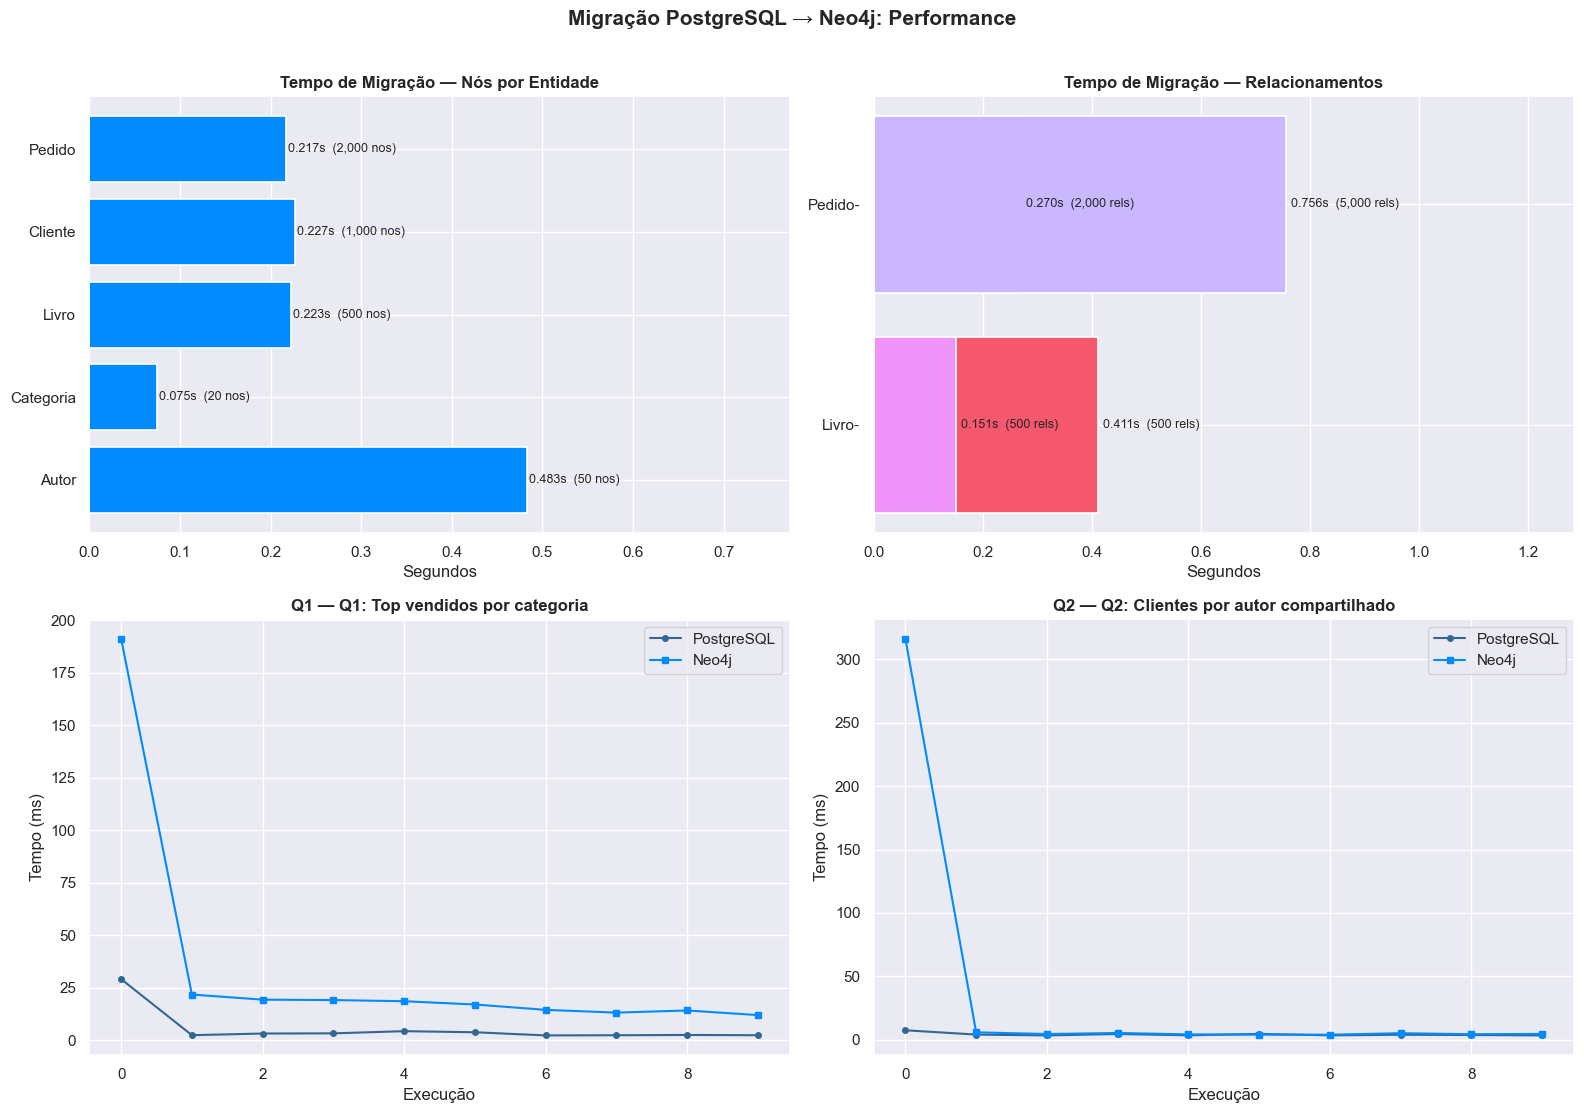

Graficos gerados com sucesso!


In [15]:
COR_PG    = '#336791'
COR_NEO   = '#018BFF'
COR_LIGHT = '#E8F4FD'

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Migração PostgreSQL → Neo4j: Performance', fontsize=15, fontweight='bold', y=1.01)

# ── 1. Tempo de Migração por Entidade ────────────────────
ax = axes[0, 0]
labels_nos  = [k for k in resultado_nos if not k.startswith('_')]
tempos_nos  = [resultado_nos[k]['tempo_s'] for k in labels_nos]
counts_nos  = [resultado_nos[k]['count']   for k in labels_nos]
bars = ax.barh(labels_nos, tempos_nos, color=COR_NEO, edgecolor='white', linewidth=1.2)
for bar, val, cnt in zip(bars, tempos_nos, counts_nos):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}s  ({cnt:,} nos)', va='center', fontsize=9)
ax.set_title('Tempo de Migração — Nós por Entidade', fontweight='bold')
ax.set_xlabel('Segundos')
ax.set_xlim(0, max(tempos_nos) * 1.6)

# ── 2. Tempo de Migração por Relacionamento ───────────────
ax = axes[0, 1]
labels_rels = [k for k in resultado_rels if not k.startswith('_')]
tempos_rels = [resultado_rels[k]['tempo_s'] for k in labels_rels]
counts_rels = [resultado_rels[k]['count']   for k in labels_rels]
short_labels = [l.split('[')[0].strip() for l in labels_rels]
bars = ax.barh(short_labels, tempos_rels, color=['#f5576c','#f093fb','#fda085','#c9b8ff'], edgecolor='white', linewidth=1.2)
for bar, val, cnt in zip(bars, tempos_rels, counts_rels):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}s  ({cnt:,} rels)', va='center', fontsize=9)
ax.set_title('Tempo de Migração — Relacionamentos', fontweight='bold')
ax.set_xlabel('Segundos')
ax.set_xlim(0, max(tempos_rels) * 1.7)

# ── 3. Benchmark Q1 ───────────────────────────────────────
ax = axes[1, 0]
r0 = resultados_bench[0]
x  = np.arange(N_BENCH_REPS)
ax.plot(x, [t * 1000 for t in r0['t_pg_arr']],  color=COR_PG,  lw=1.5, label='PostgreSQL', marker='o', ms=4)
ax.plot(x, [t * 1000 for t in r0['t_neo_arr']], color=COR_NEO, lw=1.5, label='Neo4j',      marker='s', ms=4)
ax.set_title(f'Q1 — {r0["query"].splitlines()[0]}', fontweight='bold')
ax.set_xlabel('Execução')
ax.set_ylabel('Tempo (ms)')
ax.legend()

# ── 4. Benchmark Q2 ───────────────────────────────────────
ax = axes[1, 1]
r1 = resultados_bench[1]
ax.plot(x, [t * 1000 for t in r1['t_pg_arr']],  color=COR_PG,  lw=1.5, label='PostgreSQL', marker='o', ms=4)
ax.plot(x, [t * 1000 for t in r1['t_neo_arr']], color=COR_NEO, lw=1.5, label='Neo4j',      marker='s', ms=4)
ax.set_title(f'Q2 — {r1["query"].splitlines()[0]}', fontweight='bold')
ax.set_xlabel('Execução')
ax.set_ylabel('Tempo (ms)')
ax.legend()

plt.tight_layout()
plt.savefig('migracao_pg_neo4j_resultado.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graficos gerados com sucesso!")

## 10. Conclusão

In [16]:
print("=" * 65)
print("RESUMO DA MIGRAÇÃO: PostgreSQL → Neo4j")
print("=" * 65)

total_nos  = sum(v['count'] for k, v in resultado_nos.items()  if not k.startswith('_'))
total_rels = sum(v['count'] for k, v in resultado_rels.items() if not k.startswith('_'))
print(f"\n  Nós migrados          : {total_nos:>8,}")
print(f"  Relacionamentos migr. : {total_rels:>8,}")
print(f"  Tempo total (nos)     : {resultado_nos['_total_s']:>8.2f}s")
print(f"  Tempo total (rels)    : {resultado_rels['_total_s']:>8.2f}s")

print("\n" + "-" * 65)
print(f"  {'Query':<38} {'PG (ms)':>9} {'Neo4j (ms)':>11}")
print("-" * 65)
for r in resultados_bench:
    vencedor = 'Neo4j' if r['neo4j_media_ms'] < r['pg_media_ms'] else 'PostgreSQL'
    diff = abs(r['pg_media_ms'] - r['neo4j_media_ms']) / max(r['pg_media_ms'], r['neo4j_media_ms']) * 100
    print(f"  {r['query'].splitlines()[0]:<38} {r['pg_media_ms']:>9.1f} {r['neo4j_media_ms']:>11.1f}")
    print(f"  {'→ Mais rapido: ' + vencedor + f' ({diff:.0f}% de diferenca)':<60}")

print("-" * 65)
print("""
Observacoes:
  PostgreSQL  -> excelente para agregacoes tabulares e ACID
  Neo4j       -> vence em traversals profundos (6+ JOINs equivalentes)
  Migracao    -> UNWIND+MERGE em batches e a estrategia correta
  Indice      -> obrigatorio antes de criar relacionamentos (MATCH)
  Juncao      -> tabela itens_pedido vira relacionamento com props
""")
print("=" * 65)

RESUMO DA MIGRAÇÃO: PostgreSQL → Neo4j

  Nós migrados          :    3,570
  Relacionamentos migr. :    8,000
  Tempo total (nos)     :     1.27s
  Tempo total (rels)    :     1.64s

-----------------------------------------------------------------
  Query                                    PG (ms)  Neo4j (ms)
-----------------------------------------------------------------
  Q1: Top vendidos por categoria               5.6        34.1
  → Mais rapido: PostgreSQL (84% de diferenca)                
  Q2: Clientes por autor compartilhado         4.1        35.7
  → Mais rapido: PostgreSQL (89% de diferenca)                
-----------------------------------------------------------------

Observacoes:
  PostgreSQL  -> excelente para agregacoes tabulares e ACID
  Neo4j       -> vence em traversals profundos (6+ JOINs equivalentes)
  Migracao    -> UNWIND+MERGE em batches e a estrategia correta
  Indice      -> obrigatorio antes de criar relacionamentos (MATCH)
  Juncao      -> tabela ite

---
## 11. Exercício — Adicione Resenhas

O banco já foi migrado. Sua tarefa é **estender a migração** com uma nova funcionalidade:
uma tabela de resenhas de livros feitas por clientes.

### Contexto
A equipe de produto quer saber quais livros têm as **melhores avaliações dos clientes**.
Você precisa:

1. Criar a tabela `resenhas` no PostgreSQL (o setup já está pronto abaixo)
2. Migrar para o Neo4j como relacionamento `(:Cliente)-[:AVALIOU {nota, comentario}]->(:Livro)`
3. Escrever a query Cypher para encontrar os **5 livros com melhor nota média**

### Schema da tabela
```sql
CREATE TABLE resenhas (
    id           SERIAL PRIMARY KEY,
    cliente_id   INT REFERENCES clientes(id),
    livro_id     INT REFERENCES livros(id),
    nota         SMALLINT CHECK (nota BETWEEN 1 AND 5),
    comentario   TEXT,
    data_resenha DATE
);
```

> **Dica:** Resenha é uma **tabela de relacionamento** (cliente ↔ livro) — não cria nó novo, só uma aresta `AVALIOU` entre `:Cliente` e `:Livro`!

**Execute na ordem: Setup → Sua Solução → Gabarito**

In [ ]:
# Setup do Exercicio: cria tabela resenhas e popula com dados sinteticos

def setup_exercicio(config: dict) -> int:
    conn = psycopg2.connect(**config)
    conn.autocommit = True
    cur = conn.cursor()
    cur.execute('DROP TABLE IF EXISTS resenhas')
    cur.execute("""
        CREATE TABLE resenhas (
            id           SERIAL PRIMARY KEY,
            cliente_id   INT REFERENCES clientes(id),
            livro_id     INT REFERENCES livros(id),
            nota         SMALLINT CHECK (nota BETWEEN 1 AND 5),
            comentario   TEXT,
            data_resenha DATE
        )
    """)
    resenhas = []
    for livro_id in range(1, N_LIVROS + 1):
        clientes_sel = random.sample(range(1, N_CLIENTES + 1), random.randint(1, 6))
        for cli_id in clientes_sel:
            resenhas.append({
                'cliente_id':   cli_id,
                'livro_id':     livro_id,
                'nota':         random.randint(1, 5),
                'comentario':   fake.sentence(nb_words=10),
                'data_resenha': str(fake.date_between(start_date='-1y', end_date='today'))
            })
    execute_batch(cur,
        'INSERT INTO resenhas(cliente_id,livro_id,nota,comentario,data_resenha) '
        'VALUES(%(cliente_id)s,%(livro_id)s,%(nota)s,%(comentario)s,%(data_resenha)s)',
        resenhas)
    conn.commit()
    cur.close(); conn.close()
    print(f'Setup: {len(resenhas):,} resenhas inseridas no PostgreSQL')
    return len(resenhas)

n_resenhas = setup_exercicio(PG_CONFIG)

In [ ]:
# Sua Solucao — complete as funcoes abaixo

# TAREFA 1: Leia a tabela resenhas do PostgreSQL e crie o relacionamento AVALIOU no Neo4j
# Esperado: (:Cliente {id:X})-[:AVALIOU {nota, comentario, data_resenha}]->(:Livro {id:Y})

def migrar_resenhas(pg_config, uri, user, password, batch_size=500):
    pass  # <- substitua pelo seu codigo


# TAREFA 2: Escreva a query Cypher para encontrar os 5 livros com melhor nota media
# Dica: use avg(av.nota), count(av) e filtre por total_avaliacoes >= 3

CYPHER_TOP_LIVROS = """
    -- escreva sua query aqui
"""

### Gabarito

> Execute a célula abaixo apenas após tentar sua solução!

In [ ]:
# Gabarito

def migrar_resenhas(pg_config: dict, uri: str, user: str, password: str,
                    batch_size: int = 500) -> None:
    """
    Migra resenhas como relacionamento :AVALIOU.
    Nao cria nos novos — apenas conecta :Cliente ao :Livro com propriedades.
    """
    conn   = psycopg2.connect(**pg_config)
    cur    = conn.cursor()
    driver = GraphDatabase.driver(uri, auth=(user, password))

    cur.execute('SELECT cliente_id, livro_id, nota, comentario, data_resenha FROM resenhas')
    rows = [{'cli': r[0], 'liv': r[1], 'nota': r[2],
             'com': r[3], 'data': str(r[4])} for r in cur.fetchall()]

    cypher = """
        UNWIND $lote AS row
        MATCH (c:Cliente {id: row.cli})
        MATCH (l:Livro   {id: row.liv})
        MERGE (c)-[r:AVALIOU {livro_id: row.liv}]->(l)
        SET r.nota = row.nota, r.comentario = row.com, r.data_resenha = row.data
    """

    t0 = time.perf_counter()
    with driver.session() as s:
        for i in range(0, len(rows), batch_size):
            s.run(cypher, lote=rows[i:i+batch_size])
    t = time.perf_counter() - t0

    cur.close(); conn.close(); driver.close()
    print(f'Migrados {len(rows):,} relacionamentos AVALIOU em {t:.3f}s')


migrar_resenhas(PG_CONFIG, NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, BATCH_SIZE)


# Query Cypher: Top 5 livros por nota media
CYPHER_TOP_LIVROS = """
    MATCH (c:Cliente)-[av:AVALIOU]->(l:Livro)-[:ESCRITO_POR]->(a:Autor)
    WITH l.titulo AS livro, a.nome AS autor,
         round(avg(av.nota), 2) AS nota_media,
         count(av)              AS total_avaliacoes
    WHERE total_avaliacoes >= 3
    RETURN livro, autor, nota_media, total_avaliacoes
    ORDER BY nota_media DESC, total_avaliacoes DESC
    LIMIT 5
"""

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
with driver.session() as s:
    resultado = list(s.run(CYPHER_TOP_LIVROS))
driver.close()

df_top = pd.DataFrame([dict(r) for r in resultado])
print('Top 5 Livros por Nota Media dos Clientes:')
print('=' * 60)
for i, row in df_top.iterrows():
    print(f"  {i+1}. {str(row['livro'])[:40]:<40}  nota={row['nota_media']}  ({row['total_avaliacoes']} aval.)")
    print(f"     Autor: {row['autor']}")